In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("Ads_CTR_Optimisation.csv")
N, d = df.shape


def run_ab_test(test_steps, df):
    np.random.seed(42)
    numbers_of_selections = [0] * d
    sums_of_rewards = [0] * d
    total_reward = 0

    # İlk 2.000 Müşteri
    for n in range(test_steps):
        # Her reklama eşit şans verilerek rastgele gösterilir
        ad = np.random.randint(0, d)

        reward = df.values[n, ad]
        numbers_of_selections[ad] += 1
        sums_of_rewards[ad] += reward
        total_reward += reward
    # en yüksek ortalamaya sahip reklamı bulalım
    means = [] 
    for i in range(d): 
        if numbers_of_selections[i] > 0:
            ortalama = sums_of_rewards[i] / numbers_of_selections[i] 
            means.append(ortalama)
        else:
            means.append(0)
    winning_ad = np.argmax(means)

    print("winning ad : ", (winning_ad + 1))

    #Kalan 8.000 Müşteri
    for n in range(test_steps, N):
        reward = df.values[n, winning_ad]
        numbers_of_selections[winning_ad] += 1
        sums_of_rewards[winning_ad] += reward
        total_reward += reward

    return total_reward, numbers_of_selections

ab_reward, ab_counts = run_ab_test(2000, df)
print(f"A/B Testi Toplam Tıklama Sayısı: {ab_reward}")
print(f"A/B Testi Toplam Tıklama Sayısı: {ab_counts}")


winning ad :  5
A/B Testi Toplam Tıklama Sayısı: 2388
A/B Testi Toplam Tıklama Sayısı: [224, 196, 205, 181, 8208, 191, 193, 200, 194, 208]


<function matplotlib.pyplot.show(close=None, block=None)>

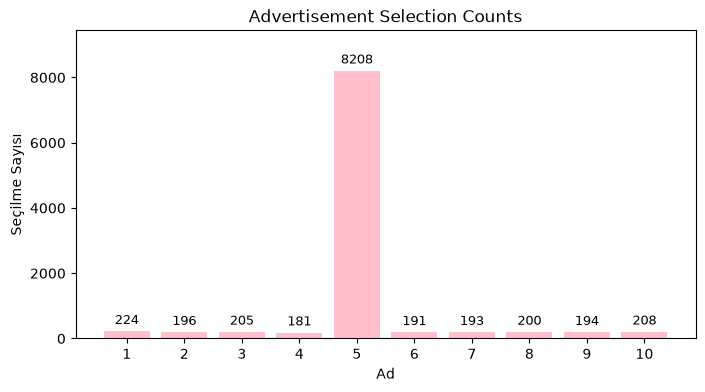

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

bars = plt.bar(range(1, d + 1), ab_counts, color='pink')

plt.bar_label(bars, padding=3, fontsize=9)
plt.ylim(0, max(ab_counts) * 1.15)

plt.xlabel("Ad")
plt.ylabel("Seçilme Sayısı")
plt.title("Advertisement Selection Counts")
plt.xticks(range(1, d + 1))

plt.show